<a href="https://colab.research.google.com/github/adarsh-crafts/BSDA5002-Mathematical-Foundations-of-Generative-AI/blob/main/03%20DC-GAN%20Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
import torchvision
import matplotlib.pyplot as plt

In [ ]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'
print(device)

mps


In [ ]:
output_dir = 'results/DC-GAN'
os.makedirs(f'{output_dir}/generated_images', exist_ok=True)
os.makedirs(f'{output_dir}/models', exist_ok=True)

## Configs

In [ ]:
z_dim = 100
img_dim = 28

batch_size = 128
learning_rate = 2e-4
epochs = 10

steps_g = 3     # generator steps per iteration
steps_d = 1     # discriminator steps per iteration

## Data

In [ ]:
transformation = transforms.Compose([
    transforms.Resize(img_dim),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transformation
)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

## GAN - Generator & Discriminator

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),    # preferable to use BatchNorm in smaller networks
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # to get img in the range of [-1, 1]
        )

    def forward(self, x):
        return self.hidden(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.hidden(x)


generator = Generator(z_dim).to(device)
discriminator = Discriminator().to(device)

In [ ]:
# loss
criterion = nn.BCELoss()

# optimizers
optimizer_g = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

In [ ]:
def generate_images(epoch):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(64, z_dim, 1, 1).to(device)
        generated_images = generator(z)
        generated_images = (generated_images + 0.5) / 0.5
        grid = torchvision.utils.make_grid(generated_images, nrow=8)
        torchvision.utils.save_image(grid, f'{output_dir}/generated_images/epoch_{epoch}.png')
    generator.train()

In [ ]:
for epoch in range(epochs):
    for batch_idx, (X, _) in enumerate(train_dataloader):
        batch_size = X.size(0)
        X = X.to(device)

        ## Train DISCRIMINATOR
        real_labels = torch.ones(size=(batch_size, 1), device=device)
        fake_labels = torch.zeros(size=(batch_size, 1), device=device)

        for _ in range(steps_d):
            # first term in D loss fn
            output_d_real = discriminator(X)
            loss_d_real = criterion(output_d_real, real_labels)

            # second term in D loss fn
            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            output_g = generator(z)
            output_d_fake = discriminator(output_g)
            loss_d_fake = criterion(output_d_fake, fake_labels)

            # total D loss
            loss_d = loss_d_real + loss_d_fake
            optimizer_d.zero_grad()
            loss_d.backward()
            optimizer_d.step()

        ## Train GENERATOR
        for _ in range(steps_g):
            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            output_g = generator(z)
            output_d_fake = discriminator(output_g)
            loss_g = criterion(output_d_fake, real_labels)
            optimizer_g.zero_grad()
            loss_g.backward()
            optimizer_g.step()

    print(f'Epoch [{epoch}/{epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}')
    generate_images(epoch)

Epoch [0/10] | Loss D: 1.1989 | Loss G: 0.8200
Epoch [1/10] | Loss D: 1.1592 | Loss G: 0.6399
Epoch [2/10] | Loss D: 1.1748 | Loss G: 1.1456
Epoch [3/10] | Loss D: 1.1596 | Loss G: 0.8206
Epoch [4/10] | Loss D: 1.1486 | Loss G: 0.7943
Epoch [5/10] | Loss D: 1.1253 | Loss G: 1.0652
Epoch [6/10] | Loss D: 1.0935 | Loss G: 1.1937
Epoch [7/10] | Loss D: 1.0456 | Loss G: 0.9340
Epoch [8/10] | Loss D: 1.1491 | Loss G: 0.7943
Epoch [9/10] | Loss D: 1.0742 | Loss G: 0.8570


## Save Model

In [ ]:
torch.save(generator.state_dict(), f'{output_dir}/models/generator.pth')

## Model Inference

In [ ]:
# load model
inference_generator = Generator(z_dim=100).to(device)
inference_generator.load_state_dict(torch.load(f'{output_dir}/models/generator.pth', map_location=device))
inference_generator.eval()

Generator(
  (hidden): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..2.999721].


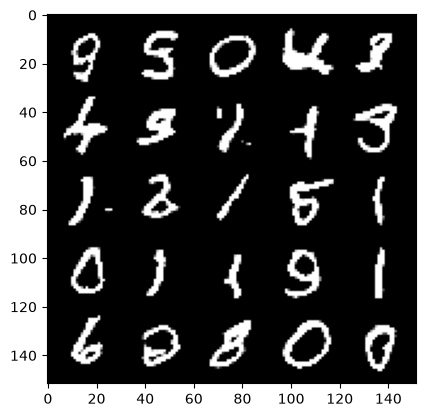

In [ ]:
z = torch.randn(25, z_dim, 1, 1).to(device)

with torch.no_grad():
    generated_images = inference_generator(z)

generated_images = (generated_images + 0.5) / 0.5   # can be changed to (gen_imgs + 1) / 2 instead
grid = torchvision.utils.make_grid(generated_images, nrow=5)
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap='gray')